# LeetCode #2: Add Two Numbers

https://leetcode.com/problems/add-two-numbers/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Integer Conversion (Brute Force)** | $O(m + n)$ | $O(\max(m, n))$ |
| **Recursive Addition** | $O(\max(m, n))$ | $O(\max(m, n))$ + call stack |
| **Iterative Addition** | $O(\max(m, n))$ | $O(\max(m, n))$ |

---

## Understanding the Methods

### Brute Force: Integer Conversion
Traverse both linked lists to extract digits, form two integers, add them, and convert the result back to a linked list. Fails when the numbers exceed 64-bit integer limits — linked lists can represent numbers with up to 100 digits.

### Recursive Addition
Same column-addition logic, but each recursive call handles one digit position and passes the carry to the next call. Same $O(\max(m, n))$ time, but adds $O(\max(m, n))$ call stack depth on top of the output space.

### Optimal: Iterative Addition ★
Mimic column addition by hand using a loop. Since the lists store digits in reverse order, the head is the least significant digit — exactly where addition starts. Walk both lists together, add corresponding digits plus any carry, and build the result node by node. No extra stack overhead.

**Why this is better than recursive:** Both produce identical results in $O(\max(m, n))$ time, but the iterative approach uses no call stack. With 100-node inputs, recursion adds 100 stack frames — the iterative version uses constant auxiliary space beyond the output list.

**Constraints:**
* Each list has 1\u2013100 nodes.
* Digits are 0\u20139, no leading zeros (except the number 0 itself).

## Solutions

### C#

In [ ]:
public class ListNode {
    public int val;
    public ListNode next;
    public ListNode(int val=0, ListNode next=null) {
        this.val = val;
        this.next = next;
    }
}

public class Solution {
    public ListNode AddTwoNumbers(ListNode l1, ListNode l2) {
        // Dummy head simplifies the logic of the first node
        ListNode dummyHead = new ListNode(0);
        ListNode current = dummyHead;
        int carry = 0;
        
        // Continue as long as there are digits or a leftover carry
        while (l1 != null || l2 != null || carry != 0) {
            // Extract values, defaulting to 0 if list is finished
            int val1 = (l1 != null) ? l1.val : 0;
            int val2 = (l2 != null) ? l2.val : 0;
            
            // Calculate sum and update carry
            int sum = val1 + val2 + carry;
            carry = sum / 10;
            
            // Create new node with the digit part of the sum
            current.next = new ListNode(sum % 10);
            current = current.next;
            
            // Move to next nodes in input lists
            if (l1 != null) l1 = l1.next;
            if (l2 != null) l2 = l2.next;
        }
        
        return dummyHead.next;
    }
}

### Python

In [ ]:
class ListNode:
    def __init__(self, val=0, next=None):
        self.val = val
        self.next = next

class Solution:
    def addTwoNumbers(self, l1: ListNode, l2: ListNode) -> ListNode:
        # Dummy head simplifies the logic of the first node
        dummy_head = ListNode(0)
        current = dummy_head
        carry = 0

        # Continue as long as there are digits or a leftover carry
        while l1 or l2 or carry:
            # Extract values, defaulting to 0 if list is finished
            val1 = l1.val if l1 else 0
            val2 = l2.val if l2 else 0

            # Calculate sum and update carry
            total = val1 + val2 + carry
            carry = total // 10

            # Create new node with the digit part of the sum
            current.next = ListNode(total % 10)
            current = current.next

            # Move to next nodes in input lists
            l1 = l1.next if l1 else None
            l2 = l2.next if l2 else None

        return dummy_head.next

### Go

In [ ]:
type ListNode struct {
    Val  int
    Next *ListNode
}

func addTwoNumbers(l1 *ListNode, l2 *ListNode) *ListNode {
    // Dummy head simplifies the logic of the first node
    dummyHead := &ListNode{}
    current := dummyHead
    carry := 0

    // Continue as long as there are digits or a leftover carry
    for l1 != nil || l2 != nil || carry != 0 {
        // Extract values, defaulting to 0 if list is finished
        val1, val2 := 0, 0
        if l1 != nil {
            val1 = l1.Val
            l1 = l1.Next
        }
        if l2 != nil {
            val2 = l2.Val
            l2 = l2.Next
        }

        // Calculate sum and update carry
        sum := val1 + val2 + carry
        carry = sum / 10

        // Create new node with the digit part of the sum
        current.Next = &ListNode{Val: sum % 10}
        current = current.Next
    }

    return dummyHead.Next
}

### Rust

In [ ]:
#[derive(PartialEq, Eq, Clone, Debug)]
pub struct ListNode {
    pub val: i32,
    pub next: Option<Box<ListNode>>,
}

impl Solution {
    pub fn add_two_numbers(
        l1: Option<Box<ListNode>>,
        l2: Option<Box<ListNode>>,
    ) -> Option<Box<ListNode>> {
        // Dummy head simplifies the logic of the first node
        let mut dummy_head = Box::new(ListNode { val: 0, next: None });
        let mut current = &mut dummy_head;
        let mut carry = 0;
        let (mut p1, mut p2) = (l1.as_deref(), l2.as_deref());

        // Continue as long as there are digits or a leftover carry
        while p1.is_some() || p2.is_some() || carry != 0 {
            // Extract values, defaulting to 0 if list is finished
            let val1 = p1.map_or(0, |n| n.val);
            let val2 = p2.map_or(0, |n| n.val);

            // Calculate sum and update carry
            let sum = val1 + val2 + carry;
            carry = sum / 10;

            // Create new node with the digit part of the sum
            current.next = Some(Box::new(ListNode { val: sum % 10, next: None }));
            current = current.next.as_mut().unwrap();

            // Move to next nodes in input lists
            p1 = p1.and_then(|n| n.next.as_deref());
            p2 = p2.and_then(|n| n.next.as_deref());
        }

        dummy_head.next
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `l1 = [2, 4, 3]`, `l2 = [5, 6, 4]` (342 + 465)  
Digits add cleanly at each position: $2+5=7$, $4+6=10$ (write 0, carry 1), $3+4+1=8$.  
**Result:** `[7, 0, 8]` (807)

### 2. Slightly Complex: Unequal Lengths
**Input:** `l1 = [9, 9]`, `l2 = [1]` (99 + 1)  
When `l2` runs out, its value defaults to 0. The carry from step 1 ripples through and creates a third node that didn't exist in either input.  
**Result:** `[0, 0, 1]` (100)

### 3. Edge Case: Time Factor (Full Carry Ripple)
**Input:** `l1 = [9, 9, 9, 9, 9, 9, 9]`, `l2 = [9, 9, 9, 9]` (9999999 + 9999)  
Every addition produces a carry that never stops — it ripples through all 7 steps and creates an 8th node. The loop runs $\max(m, n) + 1$ iterations, the worst case for time.

### 4. Edge Case: Space Factor (Single-Node Lists)
**Input:** `l1 = [0]`, `l2 = [0]` (0 + 0)  
Minimum possible input. Only 1 new node + 1 dummy head allocated — the best case for space. The algorithm handles it without any special-case code.

### 5. Almost-Impossible but Plausible: Max-Length Carry Cascade
**Input:** `l1 = [1, 0, 0, ..., 0]` (100 nodes), `l2 = [9, 9, 9, ..., 9]` (100 nines)  
Both numbers are near the 100-digit constraint limit. An integer approach would need a 333-bit number — far beyond Int64. The linked-list simulation handles it naturally with no overflow, producing a 101-node result from the final carry.

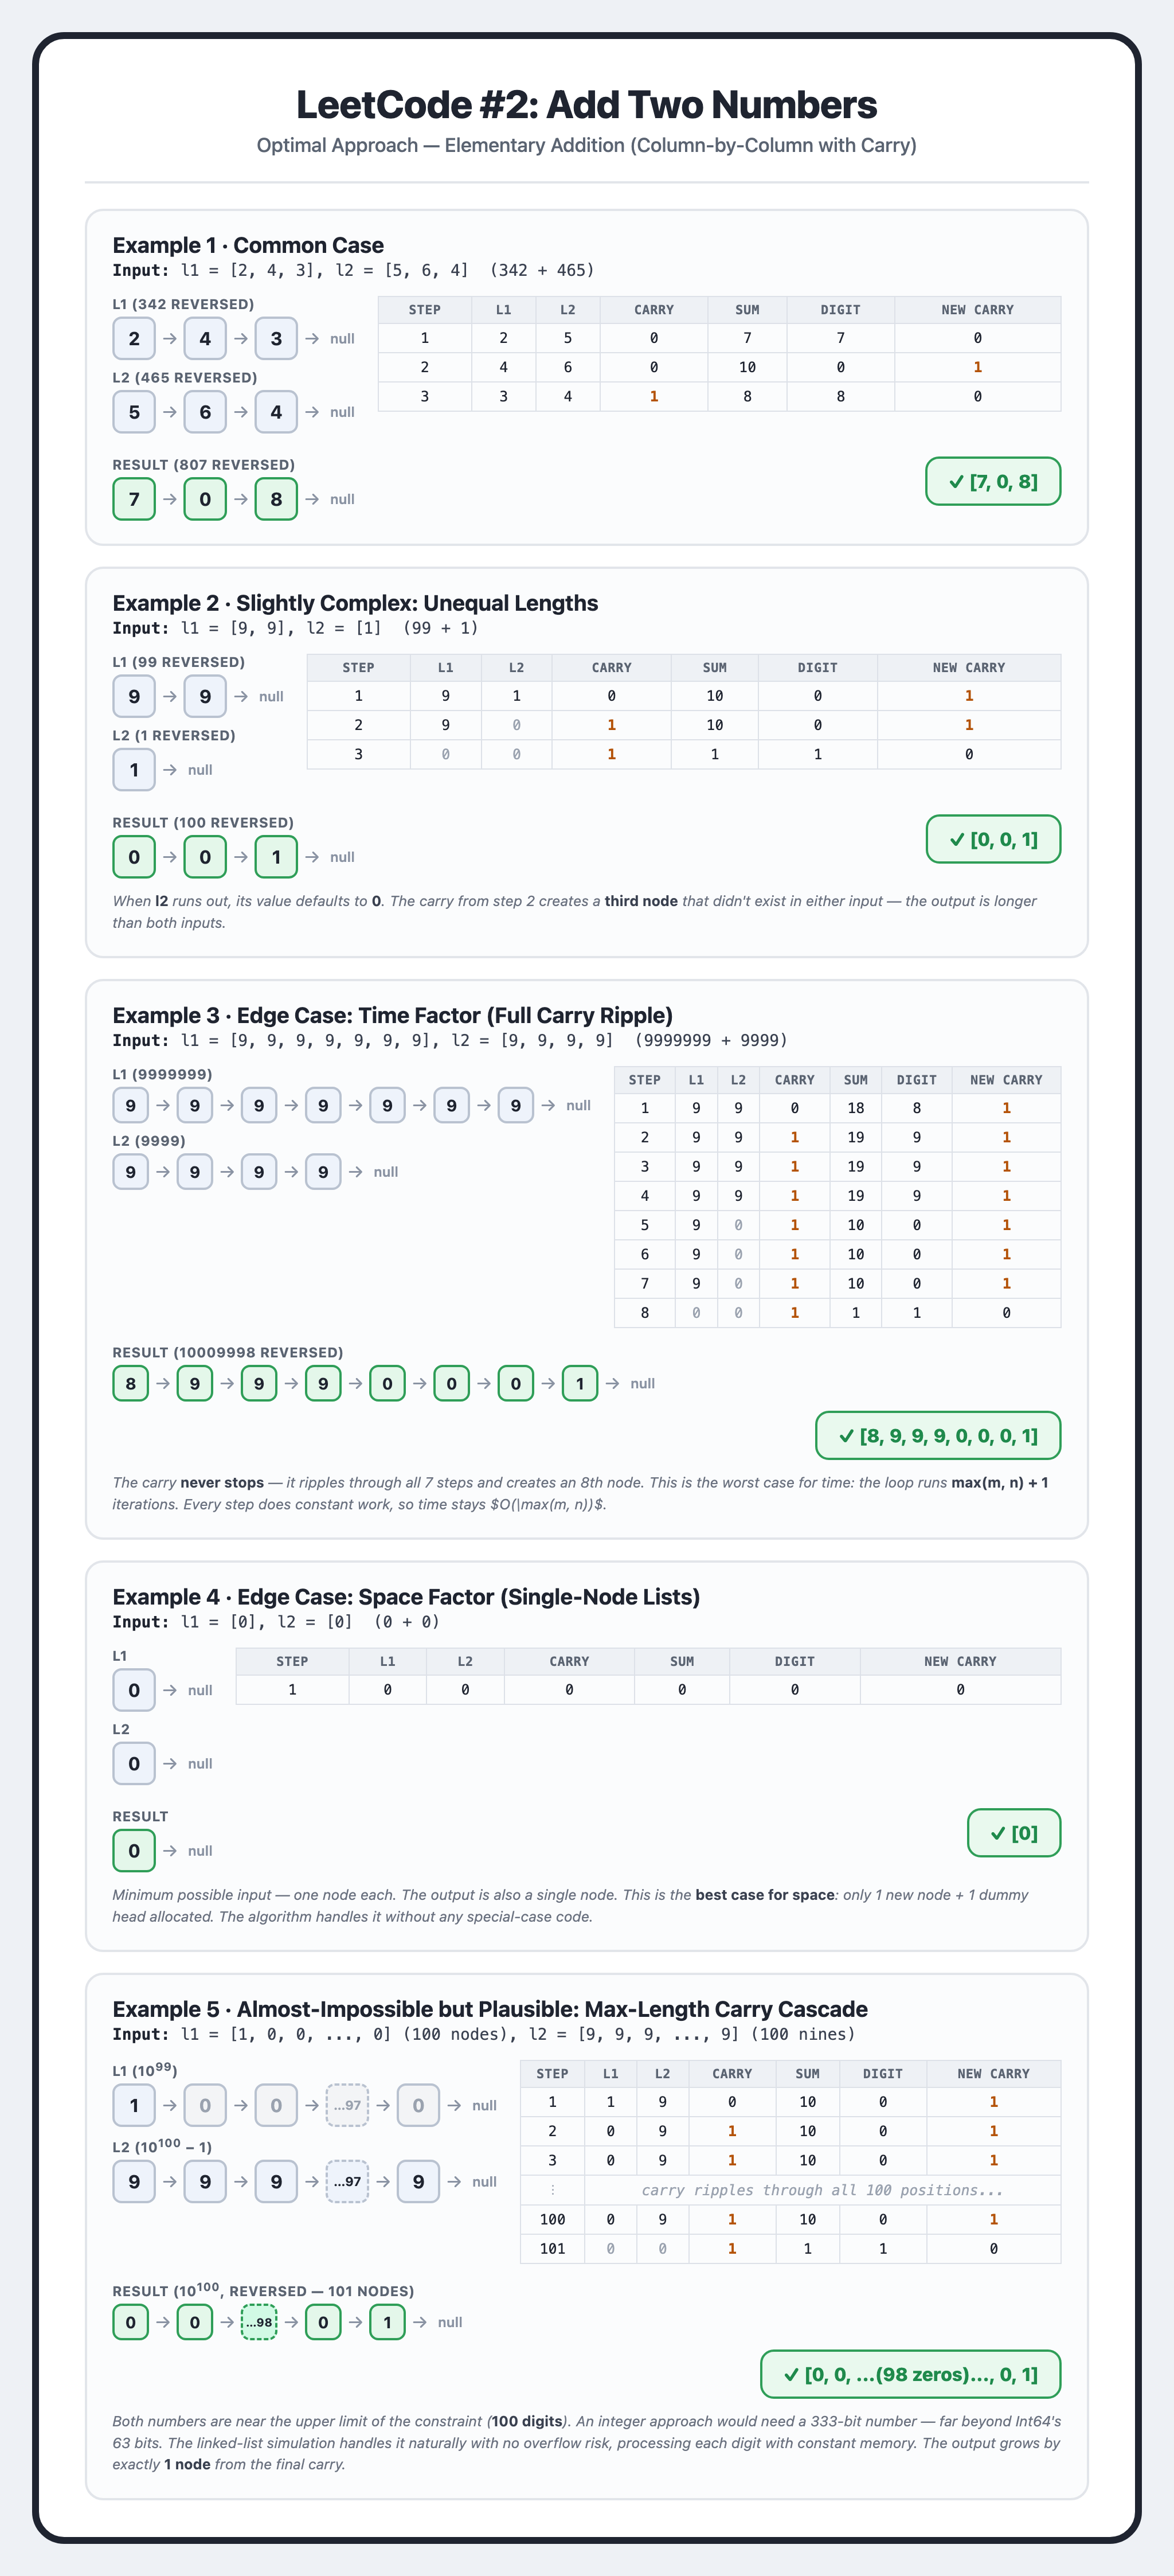